# Teste Técnico — Estágio em Dados (Abrasel)



## 1. Fonte e contexto dos dados

Os dados utilizados neste projeto pertencem ao conjunto de **Dados Abertos do CNPJ**, disponibilizado pela Receita Federal.

Para a análise, foram utilizados três arquivos do conjunto de dados:

- **Empresas0.csv:** contém uma linha por **CNPJ básico** e reúne informações cadastrais da empresa, como razão social, natureza jurídica, capital social e porte.

- **Estabelecimentos0.csv:** contém uma linha por estabelecimento e reúne informações como situação cadastral, data de início da atividade, localização e atividade econômica (CNAE).

- **simples.csv:** contém informações relacionadas à opção pelo Simples Nacional e pelo MEI. Nesta análise, essa base é utilizada principalmente para identificar quais empresas são optantes pelo **MEI**, permitindo diferenciá-las das demais Microempresas (ME).

As três bases se relacionam por meio do **CNPJ básico**, correspondente aos oito primeiros dígitos do CNPJ. O arquivo de Estabelecimentos utiliza essa chave para identificar a empresa à qual cada estabelecimento pertence, enquanto os Dados do Simples utilizam a mesma chave para associar as informações de opção pelo Simples Nacional e pelo MEI. 

O layout oficial e a descrição dos campos estão disponíveis no dicionário de dados da Receita Federal: [Documentação oficial dos Dados](https://www.gov.br/receitafederal/dados/cnpj-metadados.pdf)



---

### Empresa × estabelecimento

Uma empresa pode possuir mais de um estabelecimento.

O `cnpj_basico` identifica a empresa, enquanto o CNPJ completo identifica um
estabelecimento específico:

**CNPJ completo = CNPJ básico + ordem do estabelecimento + dígitos verificadores**

Portanto, a relação entre as tabelas Empresas e Estabelecimentos é do tipo
**1:N**.
```text
Empresa
   │
   ├── Matriz
   ├── Filial 1
   └── Filial 2
```



## 2. Configuração do ambiente

Devido ao volume dos arquivos, o **DuckDB** foi utilizado como principal mecanismo de processamento e consulta dos dados. Essa escolha permite trabalhar diretamente com grandes volumes sem a necessidade de carregar integralmente os arquivos CSV em memória, como ocorreria em uma abordagem baseada apenas em Pandas.

O **Pandas** será utilizado inicialmente para uma inspeção exploratória de pequenas amostras dos dados e, nas etapas finais, para manipular resultados já filtrados ou agregados e prepará-los para visualização.

Dessa forma, o DuckDB concentra as operações mais pesadas de leitura, transformação, junção e agregação, enquanto o Pandas é utilizado principalmente como apoio à exploração e à construção dos gráficos.

In [174]:
import duckdb as ddb
import pandas as pd
import matplotlib.pyplot as plt

csv_empresas = "empresas0.csv" 
csv_estabelecimentos = "estabelecimentos0.csv"
csv_simples = "simples.csv"

## 3. Leitura e inspeção inicial dos arquivos

Antes do processamento completo, foi realizada uma inspeção de pequenas amostras dos arquivos com Pandas. 

Os arquivos originais não possuem cabeçalho. Por isso, os nomes das colunas foram definidos manualmente a partir do layout oficial disponibilizado pela Receita Federal.



### 3.1 Empresas

O arquivo de **Empresas** possui uma linha por CNPJ básico e contém informações cadastrais da empresa, como razão social, natureza jurídica, capital social e porte.

A partir do dicionário de dados da Receita Federal, foram atribuídos nomes às sete colunas do arquivo. Para a inspeção inicial, apenas as dez primeiras linhas são carregadas com Pandas, evitando a leitura integral do arquivo em memória.


In [175]:
empresas_col_names = [
    "cnpj_basico",
    "razao_social",
    "natureza_juridica",
    "qualificacao_responsavel",
    "capital_social",
    "porte",
    "ente_federativo"
]

df_empresas = pd.read_csv(
    csv_empresas,
    sep=";",
    header=None,
    names=empresas_col_names,
    nrows=10,
    dtype=str,

)

df_empresas.head(5).style.hide()
    

cnpj_basico,razao_social,natureza_juridica,qualificacao_responsavel,capital_social,porte,ente_federativo
41273589,IRENILDA OLIVEIRA SILVA 11338767810,2135,50,"5000,00",01,nan
41273590,MARIA DAS MERCES SOARES LEMOS,4014,34,"0,00",05,nan
41273591,CASSIO APARECIDO LOPES 06457523803,2135,50,"1000,00",01,nan
41273592,41.273.592 HELIO DE JESUS PEREIRA,2135,50,"30000,00",01,nan
41273593,JULIO CESAR NUNES 39611300867,2135,50,"3000,00",01,nan


A amostra confirma a estrutura esperada para o arquivo.
| Campo | Descrição |
|---|---|
| `cnpj_basico` | Oito primeiros dígitos do CNPJ |
| `razao_social` | Razão social ou nome empresarial |
| `natureza_juridica` | Código da natureza jurídica |
| `qualificacao_responsavel` | Código da qualificação do responsável |
| `capital_social` | Capital social declarado |
| `porte` | Código de porte da empresa |
| `ente_federativo` | Ente federativo responsável, quando aplicável |

#### Dimensão do arquivo

Como uma primeira medida do volume de dados recebido, é feita a contagem das linhas do arquivo original sem carregá-lo em um DataFrame.

In [176]:
with open("empresas0.csv", "rb") as f:
    total_linhas_empresas = sum(1 for _ in f)

print(f"Total de linhas empresas: {total_linhas_empresas:,}".replace(",", "."))

Total de linhas empresas: 29.069.564


### 3.2 Estabelecimentos

O arquivo de **Estabelecimentos** possui uma granularidade diferente: cada linha representa um estabelecimento, e uma mesma empresa pode possuir uma matriz e diversas filiais.

Além das partes que compõem o CNPJ, essa base contém informações como situação cadastral, data de início da atividade, CNAE principal e secundários, localização e dados de contato.

O arquivo possui 30 campos. Assim como na base de Empresas, os nomes das colunas foram definidos a partir do layout oficial.

In [177]:
estabelecimentos_col_names = [
    "cnpj_basico",
    "cnpj_ordem",
    "cnpj_dv",
    "matriz_filial",
    "nome_fantasia",
    "situacao_cadastral",
    "data_situacao_cadastral",
    "motivo_situacao_cadastral",
    "cidade_exterior",
    "pais",
    "data_inicio_atividade",
    "cnae_principal",
    "cnae_secundaria",
    "tipo_logradouro",
    "logradouro",
    "numero",
    "complemento",
    "bairro",
    "cep",
    "uf",
    "municipio",
    "ddd_1",
    "telefone_1",
    "ddd_2",
    "telefone_2",
    "ddd_fax",
    "fax",
    "email",
    "situacao_especial",
    "data_situacao_especial"
]

df_estabelecimentos = pd.read_csv(
    csv_estabelecimentos,
    sep=";",
    header=None,
    names=estabelecimentos_col_names,
    nrows=10,
    dtype=str,
    encoding="latin-1"
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

df_estabelecimentos.head(5)

,cnpj_basico,cnpj_ordem,cnpj_dv,matriz_filial,nome_fantasia,situacao_cadastral,data_situacao_cadastral,motivo_situacao_cadastral,cidade_exterior,pais,data_inicio_atividade,cnae_principal,cnae_secundaria,tipo_logradouro,logradouro,numero,complemento,bairro,cep,uf,municipio,ddd_1,telefone_1,ddd_2,telefone_2,ddd_fax,fax,email,situacao_especial,data_situacao_especial
0,59160166,0001,18,1,NaN,02,20250129,00,NaN,NaN,20250129,5912099,4785799,RUA,CAROLINA SUCUPIRA,389,NaN,ALDEOTA,60140120,CE,1389,85,88717829,NaN,NaN,NaN,NaN,MARCELA_SHADY@HOTMAIL.COM,NaN,NaN
1,59160177,0001,06,1,NaN,02,20250129,00,NaN,NaN,20250129,1622699,4330402,3A RUA,RIO PIRATININGA,18,CASA,JARDIM SOL NASCENTE,38800000,MG,5241,37,34262407,NaN,NaN,NaN,NaN,CONTABILIDADEMORAES5@GMAIL.COM,NaN,NaN
2,53359906,0001,63,1,L.P. SOLUTION,02,20240103,00,NaN,NaN,20240103,8129000,NaN,RUA,JOSE GONCALVES PEREIRA,110,ANEXO A,CANSANCAO,45201347,BA,3661,11,47024214,NaN,NaN,NaN,NaN,JUNIORBA10@HOTMAIL.COM,NaN,NaN
3,59160197,0001,79,1,NaN,02,20250129,00,NaN,NaN,20250129,4781400,NaN,RUA,PROFESSOR PEREIRA LIRA,325,NaN,POPULAR,58304122,PB,2175,83,86770191,NaN,NaN,NaN,NaN,ESCRITORIOSULCONTABIL@GMAIL.COM,NaN,NaN
4,55371630,0001,64,1,NaN,08,20250129,01,NaN,NaN,20240603,4541206,NaN,10A RUA,SEBASTIAO FERNANDES DA COSTA,144,NaN,GURGURI,58280000,PB,2079,83,91789753,NaN,NaN,NaN,NaN,KELVIIINFERNANDES@GMAIL.COM,NaN,NaN


A inspeção inicial evidencia uma diferença importante entre as duas bases. Enquanto o `cnpj_basico` identifica a **empresa**, a identificação de cada estabelecimento depende também dos campos `cnpj_ordem` e `cnpj_dv`.

O CNPJ completo de um estabelecimento é, portanto, formado pela concatenação desses três componentes:

**CNPJ completo = CNPJ básico (8 dígitos) + ordem do estabelecimento (4 dígitos) + dígitos verificadores (2 dígitos)**

Essa estrutura permite que uma mesma empresa possua diferentes estabelecimentos, como matriz e filiais, compartilhando o mesmo `cnpj_basico`, mas com CNPJs completos distintos.

As principais colunas da tabela de Estabelecimentos para esta análise são:

| Campo | Descrição |
|---|---|
| `cnpj_basico` | Oito primeiros dígitos do CNPJ. Identifica a empresa e permite a junção com a base de Empresas. |
| `cnpj_ordem` | Número que identifica o estabelecimento dentro da empresa. |
| `cnpj_dv` | Dígitos verificadores do CNPJ. Junto com o CNPJ básico e a ordem, permite montar o CNPJ completo. |
| `matriz_filial` | Indica se o estabelecimento é matriz (`1`) ou filial (`2`). |
| `nome_fantasia` | Nome fantasia do estabelecimento, quando informado. |
| `situacao_cadastral` | Código que informa se o estabelecimento está ativo, baixado, inapto, suspenso etc. |
| `data_inicio_atividade` | Data de início das atividades do estabelecimento. |
| `cnae_principal` | Código da atividade econômica principal, utilizado para identificar os estabelecimentos do setor AFL. |
| `uf` | Unidade da Federação onde o estabelecimento está localizado. |
| `municipio` | Código do município onde o estabelecimento está localizado. |

#### Dimensão do arquivo

- Essa contagem não deve ser interpretada necessariamente como o número exato de registros. Durante a inspeção foram encontradas quebras de linha incorretas, fazendo com que um único registro CSV possa ocupar mais de uma linha física. A quantidade efetiva de estabelecimentos será validada após a ingestão utilizando o parser do DuckDB.

In [178]:
with open("estabelecimentos0.csv", "rb") as f:
    total_linhas_estabelecimentos = sum(1 for _ in f)

print(f"Total de linhas estabelecimento: {total_linhas_estabelecimentos:,}".replace(",", "."))

Total de linhas estabelecimento: 30.008.725


### 3.3 Dados do Simples

O arquivo de **Dados do Simples** possui uma linha por CNPJ básico e contém informações relacionadas à opção pelo Simples Nacional e pelo Microempreendedor Individual (MEI), incluindo as respectivas datas de opção e exclusão.

A partir do dicionário de dados da Receita Federal, foram atribuídos nomes às sete colunas do arquivo. Para a inspeção inicial, apenas as dez primeiras linhas são carregadas com Pandas, evitando a leitura integral do arquivo em memória.

Para esta análise, o campo mais relevante será `opcao_mei`, utilizado posteriormente para distinguir os Microempreendedores Individuais (MEI) das demais Microempresas (ME).

In [179]:
simples_col_names = [
    "cnpj_basico",
    "opcao_simples",
    "data_opcao_simples",
    "data_exclusao_simples",
    "opcao_mei",
    "data_opcao_mei",
    "data_exclusao_mei"
]

df_simples = pd.read_csv(
    csv_simples,
    sep=";",
    header=None,
    names=simples_col_names,
    nrows=10,
    dtype=str
)

df_simples.head(5).style.hide()

cnpj_basico,opcao_simples,data_opcao_simples,data_exclusao_simples,opcao_mei,data_opcao_mei,data_exclusao_mei
00000000,N,20070701,20070701,N,20090701,20090701
00000006,N,20180101,20191231,N,00000000,00000000
00000008,N,20140101,20211231,N,00000000,00000000
00000011,S,20070701,00000000,N,00000000,00000000
00000013,N,20090101,20231231,N,00000000,00000000


## 4. Estratégia de tratamento dos dados

Após a inspeção inicial, o processamento completo dos arquivos passa a ser realizado com **DuckDB**, permitindo trabalhar com o volume total de dados sem a necessidade de carregá-los integralmente em memória.

Para organizar as etapas de transformação, os dados foram divididos em três camadas, seguindo uma abordagem inspirada na arquitetura **Medallion**:

| Camada | Objetivo | Principais transformações |
|---|---|---|
| **Bronze** | Preservar os dados o mais próximo possível do formato original. | Leitura dos arquivos brutos, manutenção dos valores como texto e atribuição dos nomes das colunas. |
| **Silver** | Limpar, padronizar e estruturar os dados para uso analítico. | Conversão de tipos, tratamento de valores ausentes, padronização de campos, interpretação de códigos e criação do CNPJ completo. |
| **Gold** | Produzir a base final direcionada às perguntas do desafio. | Filtro dos CNAEs do setor AFL, junção entre Empresas e Estabelecimentos, seleção das variáveis relevantes e criação de campos auxiliares para análise. |

### 4.1 Estrutura do banco analítico

Os dados tratados são armazenados em um banco DuckDB local. Foram criados três schemas — `bronze`, `silver` e `gold` — para separar fisicamente as diferentes etapas do processamento.

Essa organização permite preservar os dados originalmente ingeridos, aplicar transformações de forma progressiva e manter uma camada final específica para análise.

In [225]:
import duckdb as ddb

# Cria ou abre o banco DuckDB
con = ddb.connect("database.duckdb")

# Criação das camadas
con.sql("CREATE SCHEMA IF NOT EXISTS bronze")
con.sql("CREATE SCHEMA IF NOT EXISTS silver")
con.sql("CREATE SCHEMA IF NOT EXISTS gold")

### 4.2 Camada Bronze

A camada Bronze representa o primeiro estágio de persistência dos dados. Os arquivos CSV são carregados para o DuckDB mantendo seus valores o mais próximo possível da fonte original.

Como os arquivos disponibilizados pela Receita Federal não possuem cabeçalho, os nomes das colunas são atribuídos durante a leitura com base no layout oficial.

Todos os campos são inicialmente mantidos como `VARCHAR`. Essa escolha evita conversões automáticas indesejadas e preserva códigos e identificadores que podem possuir zeros à esquerda, como partes do CNPJ.

Nesta etapa são criadas três tabelas:

- `bronze.empresas`
- `bronze.estabelecimentos`
- `bronze.simples`

#### Empresas

O arquivo de Empresas é carregado integralmente para a tabela `bronze.empresas`.

O separador `;` e os nomes das sete colunas são definidos explicitamente durante a leitura.

Nenhuma transformação de negócio é aplicada nesta etapa.

In [181]:
con.sql(f"""
    CREATE OR REPLACE TABLE bronze.empresas AS

    SELECT *
    FROM read_csv(
        '{csv_empresas}',
        delim = ';',
        header = false,
        all_varchar = true,
        encoding = 'cp1252',

        names = [
            'cnpj_basico',
            'razao_social',
            'natureza_juridica',
            'qualificacao_responsavel',
            'capital_social',
            'porte',
            'ente_federativo'
        ]
    )
""")


In [182]:
total_linhas_empresas_depois = con.sql("""
    SELECT COUNT(*) as linhas FROM bronze.empresas;
""").fetchone()[0]
print(f"Registros carregados: {total_linhas_empresas_depois:,}".replace(",", "."))

Registros carregados: 29.069.564


In [183]:
print(f"Diferença entre arquivo e Bronze: {total_linhas_empresas - total_linhas_empresas_depois}")

Diferença entre arquivo e Bronze: 0


#### Estabelecimentos

Durante a inspeção foram encontrados poucos registros com inconsistências pontuais de encoding ou parsing. Como esses casos representam uma parcela muito pequena do conjunto de dados, foi utilizado `ignore_errors = true`, permitindo que o DuckDB descarte os registros que não possam ser interpretados sem interromper a ingestão de toda a base.

In [184]:
con.sql(f"""
    CREATE OR REPLACE TABLE bronze.estabelecimentos AS

    SELECT *
    FROM read_csv(
        '{csv_estabelecimentos}',
        delim = ';',
        header = false,
        all_varchar = true,
        encoding = 'cp1252',
        ignore_errors = true,

        names = [
            'cnpj_basico',
            'cnpj_ordem',
            'cnpj_dv',
            'matriz_filial',
            'nome_fantasia',
            'situacao_cadastral',
            'data_situacao_cadastral',
            'motivo_situacao_cadastral',
            'cidade_exterior',
            'pais',
            'data_inicio_atividade',
            'cnae_principal',
            'cnae_secundaria',
            'tipo_logradouro',
            'logradouro',
            'numero',
            'complemento',
            'bairro',
            'cep',
            'uf',
            'municipio',
            'ddd_1',
            'telefone_1',
            'ddd_2',
            'telefone_2',
            'ddd_fax',
            'fax',
            'email',
            'situacao_especial',
            'data_situacao_especial'
        ]
    )
""")


In [185]:
total_linhas_estabelecimento_depois = con.sql("""
    SELECT COUNT(*) as linhas FROM bronze.estabelecimentos;
""").fetchone()[0]

print(f"Registros carregados: {total_linhas_estabelecimento_depois:,}".replace(",", "."))

Registros carregados: 30.008.722


In [186]:
print(f"Diferença entre arquivo e Bronze: {total_linhas_estabelecimentos - total_linhas_estabelecimento_depois}")

Diferença entre arquivo e Bronze: 3


#### Dados do Simples

O arquivo de Dados do Simples é carregado seguindo a mesma estratégia adotada para as demais fontes.

In [187]:
con.sql(f"""
    CREATE OR REPLACE TABLE bronze.simples AS

    SELECT *
    FROM read_csv(
        '{csv_simples}',
        delim = ';',
        header = false,
        all_varchar = true,
        encoding = 'cp1252',

        names = [
            'cnpj_basico',
            'opcao_simples',
            'data_opcao_simples',
            'data_exclusao_simples',
            'opcao_mei',
            'data_opcao_mei',
            'data_exclusao_mei'
        ]
    )
""")

In [188]:
total_simples_bronze = con.sql("""
    SELECT COUNT(*)
    FROM bronze.simples
""").fetchone()[0]

print(f"Registros carregados em bronze.simples: {total_simples_bronze:,}".replace(",", "."))

Registros carregados em bronze.simples: 49.872.124


A ingestão resultou no descarte de possíveis **3 registros** da tabela estabelecimentos, que são insignificantes dado o tamanho de registros da base.

#### Validação da camada Bronze

Após a ingestão, uma inspeção das primeiras linhas das duas tabelas foi feita para confirmar se a estrutura, os nomes das colunas e os valores foram carregados corretamente antes do início das transformações.

In [226]:
con.sql("""
    SELECT *
    FROM bronze.estabelecimentos LIMIT 5;
""").df()

,cnpj_basico,cnpj_ordem,cnpj_dv,matriz_filial,nome_fantasia,situacao_cadastral,data_situacao_cadastral,motivo_situacao_cadastral,cidade_exterior,pais,data_inicio_atividade,cnae_principal,cnae_secundaria,tipo_logradouro,logradouro,numero,complemento,bairro,cep,uf,municipio,ddd_1,telefone_1,ddd_2,telefone_2,ddd_fax,fax,email,situacao_especial,data_situacao_especial
0,59160166,0001,18,1,NaN,02,20250129,00,None,None,20250129,5912099,4785799,RUA,CAROLINA SUCUPIRA,389,NaN,ALDEOTA,60140120,CE,1389,85,88717829,None,None,None,None,MARCELA_SHADY@HOTMAIL.COM,None,None
1,59160177,0001,06,1,NaN,02,20250129,00,None,None,20250129,1622699,4330402,3A RUA,RIO PIRATININGA,18,CASA,JARDIM SOL NASCENTE,38800000,MG,5241,37,34262407,None,None,None,None,CONTABILIDADEMORAES5@GMAIL.COM,None,None
2,53359906,0001,63,1,L.P. SOLUTION,02,20240103,00,None,None,20240103,8129000,NaN,RUA,JOSE GONCALVES PEREIRA,110,ANEXO A,CANSANCAO,45201347,BA,3661,11,47024214,None,None,None,None,JUNIORBA10@HOTMAIL.COM,None,None
3,59160197,0001,79,1,NaN,02,20250129,00,None,None,20250129,4781400,NaN,RUA,PROFESSOR PEREIRA LIRA,325,NaN,POPULAR,58304122,PB,2175,83,86770191,None,None,None,None,ESCRITORIOSULCONTABIL@GMAIL.COM,None,None
4,55371630,0001,64,1,NaN,08,20250129,01,None,None,20240603,4541206,NaN,10A RUA,SEBASTIAO FERNANDES DA COSTA,144,NaN,GURGURI,58280000,PB,2079,83,91789753,None,None,None,None,KELVIIINFERNANDES@GMAIL.COM,None,None


In [227]:
con.sql("""
    SELECT *
    FROM bronze.empresas LIMIT 5;
""").df()

,cnpj_basico,razao_social,natureza_juridica,qualificacao_responsavel,capital_social,porte,ente_federativo
0,41273589,IRENILDA OLIVEIRA SILVA 11338767810,2135,50,"5000,00",01,None
1,41273590,MARIA DAS MERCES SOARES LEMOS,4014,34,"0,00",05,None
2,41273591,CASSIO APARECIDO LOPES 06457523803,2135,50,"1000,00",01,None
3,41273592,41.273.592 HELIO DE JESUS PEREIRA,2135,50,"30000,00",01,None
4,41273593,JULIO CESAR NUNES 39611300867,2135,50,"3000,00",01,None


In [228]:
con.sql("""
    SELECT *
    FROM bronze.simples LIMIT 5
""").df()

,cnpj_basico,opcao_simples,data_opcao_simples,data_exclusao_simples,opcao_mei,data_opcao_mei,data_exclusao_mei
0,00000000,N,20070701,20070701,N,20090701,20090701
1,00000006,N,20180101,20191231,N,00000000,00000000
2,00000008,N,20140101,20211231,N,00000000,00000000
3,00000011,S,20070701,00000000,N,00000000,00000000
4,00000013,N,20090101,20231231,N,00000000,00000000


Confirmamos que os dados foram carregados corretamente.

### 4.3 Camada Silver

As principais transformações realizadas nesta etapa são:

- conversão de campos de data para o tipo `DATE`;
- conversão de valores monetários para tipos numéricos adequados;
- tratamento de strings vazias e espaços excedentes;
- padronização de campos textuais;
- manutenção dos códigos originais acompanhados de descrições mais legíveis para `porte`, `situacao_cadastral` e `matriz_filial`;
- criação do CNPJ completo de 14 dígitos na tabela de Estabelecimentos.

Campos que representam identificadores ou códigos, como CNPJ, CNAE, CEP e telefone, permanecem como texto para preservar zeros à esquerda e evitar interpretações numéricas inadequadas.

#### Estabelecimentos

Na tabela de Estabelecimentos, além da limpeza dos campos textuais, são convertidas as colunas de data e criadas descrições para códigos cadastrais.

Também é construído o **CNPJ completo**, concatenando `cnpj_basico`, `cnpj_ordem` e `cnpj_dv`.

In [192]:
con.sql("""
    CREATE OR REPLACE TABLE silver.estabelecimentos AS

    SELECT
        -- Identificadores CNPJ
        cnpj_basico,
        cnpj_ordem,
        cnpj_dv,

        cnpj_basico || cnpj_ordem || cnpj_dv AS cnpj,   -- CNPJ COMPLETO

        -- Matriz / filial
        matriz_filial AS matriz_filial_codigo, 

        CASE matriz_filial
            WHEN '1' THEN 'Matriz'
            WHEN '2' THEN 'Filial'
            ELSE NULL
        END AS matriz_filial_descricao,

        -- Nome
        NULLIF(TRIM(nome_fantasia), '') AS nome_fantasia, -- remove espaço ou vira null

        -- Situação cadastral
        situacao_cadastral AS situacao_cadastral_codigo,

        CASE TRY_CAST(situacao_cadastral AS INTEGER) -- converte para inteiro para que 01 e 1 sejam incluidos
            WHEN '1' THEN 'Nula'
            WHEN '2' THEN 'Ativa'
            WHEN '3' THEN 'Suspensa'
            WHEN '4' THEN 'Inapta'
            WHEN '8' THEN 'Baixada'
            ELSE NULL
        END AS situacao_cadastral_descricao,

        -- Datas -> converte para o formato DATE (ex: '20250129' vira 2025-01-29)
        TRY_STRPTIME(NULLIF(data_situacao_cadastral, ''),'%Y%m%d' )::DATE AS data_situacao_cadastral,

        motivo_situacao_cadastral,

        NULLIF(TRIM(cidade_exterior), '') AS cidade_exterior,
        pais,

        -- Converte para DATE
        TRY_STRPTIME(NULLIF(data_inicio_atividade, ''),'%Y%m%d' )::DATE AS data_inicio_atividade,
            
        -- CNAE
        cnae_principal,
        NULLIF(TRIM(cnae_secundaria), '') AS cnae_secundaria,

        -- Endereço
        NULLIF(TRIM(tipo_logradouro), '') AS tipo_logradouro,
        NULLIF(TRIM(logradouro), '') AS logradouro,
        NULLIF(TRIM(numero), '') AS numero,
        NULLIF(TRIM(complemento), '') AS complemento,
        NULLIF(TRIM(bairro), '') AS bairro,

        cep,
        UPPER(NULLIF(TRIM(uf), '')) AS uf, -- converte para maiusculo
        municipio,

        -- Contato
        NULLIF(TRIM(ddd_1), '') AS ddd_1,
        NULLIF(TRIM(telefone_1), '') AS telefone_1,
        NULLIF(TRIM(ddd_2), '') AS ddd_2,
        NULLIF(TRIM(telefone_2), '') AS telefone_2,
        NULLIF(TRIM(ddd_fax), '') AS ddd_fax,
        NULLIF(TRIM(fax), '') AS fax,

        LOWER(NULLIF(TRIM(email), '')) AS email,

        -- Situação especial
        NULLIF(TRIM(situacao_especial), '') AS situacao_especial,

        TRY_STRPTIME(NULLIF(data_situacao_especial, ''),'%Y%m%d')::DATE AS data_situacao_especial
            
    FROM bronze.estabelecimentos
""")


##### Validação

Após a transformação, são verificados os tipos das colunas e a quantidade de registros para confirmar que a criação da Silver não removeu linhas de forma não intencional.

In [193]:
con.sql("""
    DESCRIBE silver.estabelecimentos
""").df()

,column_name,column_type,null,key,default,extra
0,cnpj_basico,VARCHAR,YES,None,None,None
1,cnpj_ordem,VARCHAR,YES,None,None,None
2,cnpj_dv,VARCHAR,YES,None,None,None
3,cnpj,VARCHAR,YES,None,None,None
4,matriz_filial_codigo,VARCHAR,YES,None,None,None
5,matriz_filial_descricao,VARCHAR,YES,None,None,None
6,nome_fantasia,VARCHAR,YES,None,None,None
7,situacao_cadastral_codigo,VARCHAR,YES,None,None,None
8,situacao_cadastral_descricao,VARCHAR,YES,None,None,None
9,data_situacao_cadastral,DATE,YES,None,None,None


In [194]:
total_estabelecimentos_silver = con.sql("""
    SELECT COUNT(*)
    FROM silver.estabelecimentos
""").fetchone()[0]

print(f"Bronze: {total_linhas_estabelecimento_depois:,}".replace(",", "."))
print(f"Silver: {total_estabelecimentos_silver:,}".replace(",", "."))

Bronze: 30.008.722
Silver: 30.008.722


#### Empresas

Na tabela de Empresas, as principais transformações consistem na padronização dos campos textuais, conversão do capital social para um tipo numérico e interpretação do código de porte.

O `cnpj_basico` permanece como texto, pois funciona como identificador da empresa e pode conter zeros à esquerda. O mesmo princípio é aplicado aos demais campos que representam códigos.

O campo `capital_social`, originalmente armazenado como texto e utilizando vírgula como separador decimal, é convertido para `DECIMAL(18,2)`.

Para o campo `porte`, o código original é preservado e uma coluna descritiva é adicionada para facilitar as análises posteriores.

In [195]:
### Empresas

con.sql("""
    CREATE OR REPLACE TABLE silver.empresas AS

    SELECT
        -- Identificador
        NULLIF(TRIM(cnpj_basico), '') AS cnpj_basico,

        -- Dados cadastrais
        NULLIF(TRIM(razao_social), '') AS razao_social,

        NULLIF(TRIM(natureza_juridica), '') AS natureza_juridica_codigo,

        NULLIF(TRIM(qualificacao_responsavel), '') AS qualificacao_responsavel_codigo,

        -- Capital social -> converte para numero caso seja possivel
        TRY_CAST(REPLACE(NULLIF(TRIM(capital_social), ''),',','.')AS DECIMAL(18,2)) AS capital_social,
        
        -- Porte
        porte AS porte_codigo,

        CASE TRY_CAST(porte AS INTEGER)
            WHEN 0 THEN 'Não informado'
            WHEN 1 THEN 'Microempresa'
            WHEN 3 THEN 'Empresa de pequeno porte'
            WHEN 5 THEN 'Demais'
            ELSE NULL
        END AS porte_descricao,

        -- Ente federativo
        NULLIF(TRIM(ente_federativo), '') AS ente_federativo

    FROM bronze.empresas
""")

##### Validação

In [196]:
con.sql("""
    DESCRIBE silver.empresas
""").df()

,column_name,column_type,null,key,default,extra
0,cnpj_basico,VARCHAR,YES,None,None,None
1,razao_social,VARCHAR,YES,None,None,None
2,natureza_juridica_codigo,VARCHAR,YES,None,None,None
3,qualificacao_responsavel_codigo,VARCHAR,YES,None,None,None
4,capital_social,"DECIMAL(18,2)",YES,None,None,None
5,porte_codigo,VARCHAR,YES,None,None,None
6,porte_descricao,VARCHAR,YES,None,None,None
7,ente_federativo,VARCHAR,YES,None,None,None


In [197]:
total_empresas_silver = con.sql("""
    SELECT COUNT(*)
    FROM silver.empresas
""").fetchone()[0]

print(f"Bronze: {total_linhas_empresas_depois:,}".replace(",", "."))
print( f"Silver: {total_empresas_silver:,}".replace(",", "."))

Bronze: 29.069.564
Silver: 29.069.564


#### Dados do Simples

Os indicadores de opção pelo **Simples Nacional** e pelo **MEI** são preservados em suas formas originais (`S`, `N` ou vazio) e também recebem colunas descritivas para facilitar a interpretação nas análises posteriores.


In [198]:
con.sql("""
    CREATE OR REPLACE TABLE silver.simples AS

    SELECT
        -- Identificador
        NULLIF(TRIM(cnpj_basico), '') AS cnpj_basico,

        -- Opção pelo Simples Nacional
        NULLIF(UPPER(TRIM(opcao_simples)), '') AS opcao_simples_codigo,

        CASE UPPER(TRIM(opcao_simples))
            WHEN 'S' THEN 'Sim'
            WHEN 'N' THEN 'Não'
            WHEN '' THEN 'Outros'
            ELSE NULL
        END AS opcao_simples_descricao,

        -- Datas relacionadas ao Simples
        TRY_STRPTIME(NULLIF(data_opcao_simples, ''), '%Y%m%d' )::DATE AS data_opcao_simples,
            
        TRY_STRPTIME(NULLIF(data_exclusao_simples, ''),'%Y%m%d')::DATE AS data_exclusao_simples,
          
        -- Opção pelo MEI
        NULLIF(UPPER(TRIM(opcao_mei)), '') AS opcao_mei_codigo,

        CASE UPPER(TRIM(opcao_mei))
            WHEN 'S' THEN 'Sim'
            WHEN 'N' THEN 'Não'
            WHEN '' THEN 'Outros'
            ELSE NULL
        END AS opcao_mei_descricao,

        -- Datas relacionadas ao MEI
        TRY_STRPTIME(NULLIF(data_opcao_mei, ''), '%Y%m%d')::DATE AS data_opcao_mei,
        
        TRY_STRPTIME(NULLIF(data_exclusao_mei, ''),'%Y%m%d' )::DATE AS data_exclusao_mei

    FROM bronze.simples
""")

In [199]:
con.sql("""
    DESCRIBE silver.simples
""").df()

,column_name,column_type,null,key,default,extra
0,cnpj_basico,VARCHAR,YES,None,None,None
1,opcao_simples_codigo,VARCHAR,YES,None,None,None
2,opcao_simples_descricao,VARCHAR,YES,None,None,None
3,data_opcao_simples,DATE,YES,None,None,None
4,data_exclusao_simples,DATE,YES,None,None,None
5,opcao_mei_codigo,VARCHAR,YES,None,None,None
6,opcao_mei_descricao,VARCHAR,YES,None,None,None
7,data_opcao_mei,DATE,YES,None,None,None
8,data_exclusao_mei,DATE,YES,None,None,None


#### Inspeção das tabelas Silver

Após as transformações, é realizada uma inspeção das primeiras linhas das tabelas Silver para verificar se os dados foram padronizados conforme o esperado.

In [229]:
con.sql( """SELECT * FROM silver.empresas LIMIT 5;""").df()

,cnpj_basico,razao_social,natureza_juridica_codigo,qualificacao_responsavel_codigo,capital_social,porte_codigo,porte_descricao,ente_federativo
0,41273589,IRENILDA OLIVEIRA SILVA 11338767810,2135,50,5000.0,01,Microempresa,None
1,41273590,MARIA DAS MERCES SOARES LEMOS,4014,34,0.0,05,Demais,None
2,41273591,CASSIO APARECIDO LOPES 06457523803,2135,50,1000.0,01,Microempresa,None
3,41273592,41.273.592 HELIO DE JESUS PEREIRA,2135,50,30000.0,01,Microempresa,None
4,41273593,JULIO CESAR NUNES 39611300867,2135,50,3000.0,01,Microempresa,None


In [230]:
con.sql(""" SELECT * FROM silver.estabelecimentos LIMIT 5; """).df()

,cnpj_basico,cnpj_ordem,cnpj_dv,cnpj,matriz_filial_codigo,matriz_filial_descricao,nome_fantasia,situacao_cadastral_codigo,situacao_cadastral_descricao,data_situacao_cadastral,motivo_situacao_cadastral,cidade_exterior,pais,data_inicio_atividade,cnae_principal,cnae_secundaria,tipo_logradouro,logradouro,numero,complemento,bairro,cep,uf,municipio,ddd_1,telefone_1,ddd_2,telefone_2,ddd_fax,fax,email,situacao_especial,data_situacao_especial
0,59160166,0001,18,59160166000118,1,Matriz,NaN,02,Ativa,2025-01-29,00,None,None,2025-01-29,5912099,4785799,RUA,CAROLINA SUCUPIRA,389,NaN,ALDEOTA,60140120,CE,1389,85,88717829,None,None,None,None,marcela_shady@hotmail.com,None,NaT
1,59160177,0001,06,59160177000106,1,Matriz,NaN,02,Ativa,2025-01-29,00,None,None,2025-01-29,1622699,4330402,3A RUA,RIO PIRATININGA,18,CASA,JARDIM SOL NASCENTE,38800000,MG,5241,37,34262407,None,None,None,None,contabilidademoraes5@gmail.com,None,NaT
2,53359906,0001,63,53359906000163,1,Matriz,L.P. SOLUTION,02,Ativa,2024-01-03,00,None,None,2024-01-03,8129000,NaN,RUA,JOSE GONCALVES PEREIRA,110,ANEXO A,CANSANCAO,45201347,BA,3661,11,47024214,None,None,None,None,juniorba10@hotmail.com,None,NaT
3,59160197,0001,79,59160197000179,1,Matriz,NaN,02,Ativa,2025-01-29,00,None,None,2025-01-29,4781400,NaN,RUA,PROFESSOR PEREIRA LIRA,325,NaN,POPULAR,58304122,PB,2175,83,86770191,None,None,None,None,escritoriosulcontabil@gmail.com,None,NaT
4,55371630,0001,64,55371630000164,1,Matriz,NaN,08,Baixada,2025-01-29,01,None,None,2024-06-03,4541206,NaN,10A RUA,SEBASTIAO FERNANDES DA COSTA,144,NaN,GURGURI,58280000,PB,2079,83,91789753,None,None,None,None,kelviiinfernandes@gmail.com,None,NaT


In [231]:
con.sql(""" SELECT * FROM silver.simples LIMIT 5; """).df()

,cnpj_basico,opcao_simples_codigo,opcao_simples_descricao,data_opcao_simples,data_exclusao_simples,opcao_mei_codigo,opcao_mei_descricao,data_opcao_mei,data_exclusao_mei
0,00000000,N,Não,2007-07-01,2007-07-01,N,Não,2009-07-01,2009-07-01
1,00000006,N,Não,2018-01-01,2019-12-31,N,Não,NaT,NaT
2,00000008,N,Não,2014-01-01,2021-12-31,N,Não,NaT,NaT
3,00000011,S,Sim,2007-07-01,NaT,N,Não,NaT,NaT
4,00000013,N,Não,2009-01-01,2023-12-31,N,Não,NaT,NaT


A inspeção confirma que as principais transformações da camada Silver foram aplicadas corretamente. As bases permanecem separadas e mantêm sua granularidade original, mas agora estão estruturadas e prontas para a construção da camada Gold.

### 4.4 Camada Gold

A camada Gold contém a base final preparada especificamente para responder às perguntas propostas no desafio.

Nesta etapa são aplicadas as transformações relacionadas ao objetivo da análise:

- filtro dos estabelecimentos pelos seis CNAEs definidos no desafio;
- junção entre Empresas e Estabelecimentos por meio do `cnpj_basico`;
- incorporação das informações do Simples Nacional e do MEI;
- seleção das variáveis relevantes para as análises;
- criação das descrições dos CNAEs utilizados no filtro;
- criação de variáveis auxiliares, como o ano de abertura e a classificação de porte.

A tabela resultante possui granularidade de **estabelecimento**. Portanto, uma mesma empresa pode aparecer em mais de uma linha caso possua múltiplos estabelecimentos pertencentes ao setor analisado.

#### Cobertura da amostra

O teste propõe trabalhar com apenas uma das dez partes disponibilizadas para Empresas e Estabelecimentos, sem utilizar a base nacional completa.

Durante a validação da junção entre as duas tabelas selecionadas, foi identificado que nem todos os estabelecimentos presentes em `Estabelecimentos0` possuem um `cnpj_basico` correspondente em `Empresas0`.

Entre os **2.142.964 estabelecimentos** identificados na amostra de Estabelecimentos:

- **912.629** possuem correspondência na tabela de Empresas;
- **1.230.335** não possuem correspondência, representando aproximadamente **57,4%** dos estabelecimentos AFL encontrados.

Dessa forma, iremos manter essa amostra e utilizar na base analítica somente os registros que possuem informações disponíveis nas duas tabelas.

#### Construção da base analítica

A construção da tabela Gold combina as três fontes tratadas nas etapas anteriores.

Para relacionar Estabelecimentos e Empresas é utilizado um `INNER JOIN` por meio do `cnpj_basico`, mantendo somente os estabelecimentos que possuem uma empresa correspondente na amostra de Empresas.

Em seguida, os Dados do Simples são incorporados por meio de um `LEFT JOIN`, também utilizando o `cnpj_basico`. Dessa forma, as informações sobre opção pelo Simples Nacional e pelo MEI são adicionadas quando disponíveis, sem eliminar registros já pertencentes à base analítica.

A informação de opção pelo MEI será combinada posteriormente com o campo de porte da tabela de Empresas, permitindo distinguir **MEI, ME, EPP, Demais e Não informado**.

In [203]:
con.sql("""
    CREATE OR REPLACE TABLE gold.analise AS

    SELECT

        -- Identificação
        est.cnpj,
        est.cnpj_basico,
        emp.razao_social,
        est.nome_fantasia,

        -- Matriz / filial
        est.matriz_filial_codigo,
        est.matriz_filial_descricao,

        -- Situação cadastral
        est.situacao_cadastral_codigo,
        est.situacao_cadastral_descricao,

        -- Abertura
        est.data_inicio_atividade,
        YEAR(est.data_inicio_atividade) AS ano_abertura,

        -- Atividade econômica
        est.cnae_principal,

        CASE est.cnae_principal
            WHEN '4721102'
                THEN 'Padaria e confeitaria com predominância de revenda'
            WHEN '5611201'
                THEN 'Restaurantes e similares'
            WHEN '5611203'
                THEN 'Lanchonetes, casas de chá, de sucos e similares'
            WHEN '5611204'
                THEN 'Bares sem entretenimento'
            WHEN '5611205'
                THEN 'Bares com entretenimento'
            WHEN '5620104'
                THEN 'Fornecimento de alimentos preparados para consumo domiciliar'
        END AS cnae_descricao,

        -- Porte original da tabela Empresas
        emp.porte_codigo,
        emp.porte_descricao,
        emp.capital_social,

        -- Informações do Simples / MEI
        simp.opcao_simples_codigo,
        simp.opcao_mei_codigo,

        -- Classificação utilizada na análise
        CASE
            WHEN simp.opcao_mei_codigo = 'S'
                THEN 'MEI'

            WHEN TRY_CAST(emp.porte_codigo AS INTEGER) = 1
                THEN 'ME'

            WHEN TRY_CAST(emp.porte_codigo AS INTEGER) = 3
                THEN 'EPP'

            WHEN TRY_CAST(emp.porte_codigo AS INTEGER) = 5
                THEN 'Demais'

            ELSE 'Não informado'
        END AS classificacao_porte,

        -- Localização
        est.municipio,
        est.uf

    FROM silver.estabelecimentos est

    INNER JOIN silver.empresas emp
        ON est.cnpj_basico = emp.cnpj_basico

    LEFT JOIN silver.simples simp
        ON est.cnpj_basico = simp.cnpj_basico

    -- Filtro do setor AFL
    WHERE est.cnae_principal IN (
        '4721102',
        '5611201',
        '5611203',
        '5611204',
        '5611205',
        '5620104'
    )
""")

#### Validação da base Gold

Após a construção da tabela final, são verificadas a quantidade de estabelecimentos e a quantidade de empresas distintas presentes na amostra analítica.

In [204]:
con.sql("""
    SELECT
        COUNT(*) AS estabelecimentos,
        COUNT(DISTINCT cnpj_basico) AS empresas
    FROM gold.analise
""").df()

,estabelecimentos,empresas
0,912629,905757


A tabela `gold.analise` passa a representar a base utilizada nas análises seguintes. Cada linha corresponde a um estabelecimento que possui informações disponíveis tanto na amostra de Estabelecimentos quanto na amostra de Empresas.

In [232]:
con.sql("""SELECT * FROM gold.analise LIMIT 5;""").df()

,cnpj,cnpj_basico,razao_social,nome_fantasia,matriz_filial_codigo,matriz_filial_descricao,situacao_cadastral_codigo,situacao_cadastral_descricao,data_inicio_atividade,ano_abertura,cnae_principal,cnae_descricao,porte_codigo,porte_descricao,capital_social,opcao_simples_codigo,opcao_mei_codigo,classificacao_porte,municipio,uf
0,41920888000168,41920888,VALDIR DOS SANTOS 43029329100,NaN,1,Matriz,04,Inapta,2021-05-12,2021,5611204,Bares sem entretenimento,01,Microempresa,1500.0,S,S,MEI,9753,GO
1,41920961000100,41920961,CRISTIANO ARAUJO DA SILVA 60264856350,MESTRE DO SABOR,1,Matriz,04,Inapta,2021-05-12,2021,5611201,Restaurantes e similares,01,Microempresa,20000.0,S,N,ME,6001,RJ
2,41920962000146,41920962,JORGE WARMILING 65706595968,NaN,1,Matriz,04,Inapta,2021-05-12,2021,5611203,"Lanchonetes, casas de chá, de sucos e similares",01,Microempresa,5000.0,S,S,MEI,8137,SC
3,41920995000196,41920995,EDIVANE MARIA DE JESUS 03199889530,NaN,1,Matriz,04,Inapta,2021-05-12,2021,5611205,Bares com entretenimento,01,Microempresa,5000.0,S,S,MEI,3965,BA
4,41921018000103,41921018,41.921.018 JOAS HENRIQUE DO NASCIMENTO ARAUJO,NaN,1,Matriz,04,Inapta,2021-05-12,2021,5611203,"Lanchonetes, casas de chá, de sucos e similares",01,Microempresa,1000.0,N,N,ME,7145,SP


## 5. Análise dos dados

### 5.1 Quantas empresas do setor estão ativas?

A situação cadastral disponível na base é uma característica do **estabelecimento**, enquanto uma mesma empresa pode possuir uma matriz e múltiplas filiais.

Por isso, é necessário definir uma regra para consolidar a situação dos estabelecimentos no nível da empresa.

Para responder inicialmente à pergunta proposta no desafio, será considerada **ativa** toda empresa que possua **pelo menos um estabelecimento com situação cadastral `Ativa`**.

Como uma mesma empresa pode possuir vários estabelecimentos ativos, a contagem é realizada sobre os valores distintos de `cnpj_basico`, evitando que uma empresa seja contabilizada mais de uma vez.

In [206]:
total_empresas = con.sql("""
    SELECT COUNT(DISTINCT cnpj_basico)
    FROM gold.analise
""").fetchone()[0]

empresas_ativas = con.sql("""
    SELECT COUNT(DISTINCT cnpj_basico)
    FROM gold.analise
    WHERE situacao_cadastral_descricao = 'Ativa'
""").fetchone()[0]

percentual_ativas = empresas_ativas / total_empresas * 100

print(f"Total de empresas na amostra: {total_empresas:,}".replace(",", "."))
print(f"Empresas ativas na amostra: {empresas_ativas:,}".replace(",", "."))
print(f"Percentual de empresas ativas: {percentual_ativas:.2f}%")

Total de empresas na amostra: 905.757
Empresas ativas na amostra: 433.735
Percentual de empresas ativas: 47.89%


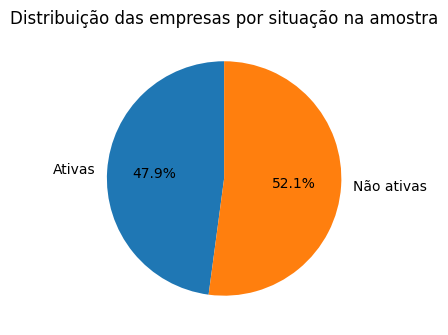

In [207]:
empresas_nao_ativas = total_empresas - empresas_ativas

valores = [empresas_ativas, empresas_nao_ativas]
rotulos = ["Ativas", "Não ativas"]

fig, ax = plt.subplots(figsize=(4, 4))

ax.pie(
    valores,
    labels=rotulos,
    autopct="%1.1f%%",
    startangle=90
)

ax.set_title("Distribuição das empresas por situação na amostra")

plt.tight_layout()
plt.show()

Na amostra analisada, **433.735 das 905.757 empresas possuem pelo menos um estabelecimento ativo**, correspondendo a **47,89% do total**.

As demais **472.022 empresas (52,11%)** não possuem nenhum estabelecimento classificado como ativo entre os registros disponíveis na amostra.


#### Análise complementar: situação consolidada da empresa

A classificação anterior considera suficiente a existência de um único estabelecimento ativo. Para avaliar se essa escolha influencia significativamente o resultado, foi construída uma segunda classificação, considerando conjuntamente todos os estabelecimentos de cada empresa.

A regra utilizada é:

- se todos os estabelecimentos possuem a mesma situação cadastral, a empresa recebe essa situação;
- se a empresa possui estabelecimentos em situações diferentes, ela é classificada como **"Possui estabelecimentos em diferentes categorias"**.

Essa análise permite identificar empresas cuja situação não pode ser representada adequadamente por uma única categoria cadastral.

In [208]:
situacao_empresas = con.sql("""
    SELECT
        cnpj_basico,

        -- Quantidade de estabelecimentos da empresa presentes na amostra
        COUNT(*) AS qtd_estabelecimentos,

        CASE
            -- Conta quantas situações cadastrais diferentes existem entre os estabelecimentos da mesma empresa
            WHEN COUNT(
                DISTINCT COALESCE(
                    situacao_cadastral_descricao,
                    'Não informado'
                )
            ) = 1

            -- Se existe apenas uma situação distinta,todos os estabelecimentos estão na mesma categoria.
            -- O MAX apenas recupera esse único valor.

            THEN MAX(
                COALESCE(
                    situacao_cadastral_descricao,
                    'Não informado'
                )
            )

            -- Caso existam duas ou mais situações diferentes,
            -- a empresa recebe uma classificação própria
            
            ELSE 'Possui estabelecimentos em diferentes categorias'

        END AS situacao_empresa

    FROM gold.analise

    -- Agrupa todos os estabelecimentos pertencentes à mesma empresa
    GROUP BY cnpj_basico
""").df()


In [209]:
resumo_situacao_empresas = (
    situacao_empresas
    .groupby("situacao_empresa")
    .size()
    .reset_index(name="empresas")
    .sort_values("empresas", ascending=False)
)

resumo_situacao_empresas["percentual"] = (
    resumo_situacao_empresas["empresas"]
    / resumo_situacao_empresas["empresas"].sum()
    * 100
)

resumo_situacao_empresas

,situacao_empresa,empresas,percentual
0,Ativa,433236,47.831372
1,Baixada,386051,42.621917
2,Inapta,83968,9.270478
5,Suspensa,1455,0.160639
4,Possui estabelecimentos em diferentes categorias,607,0.067016
3,Nula,440,0.048578


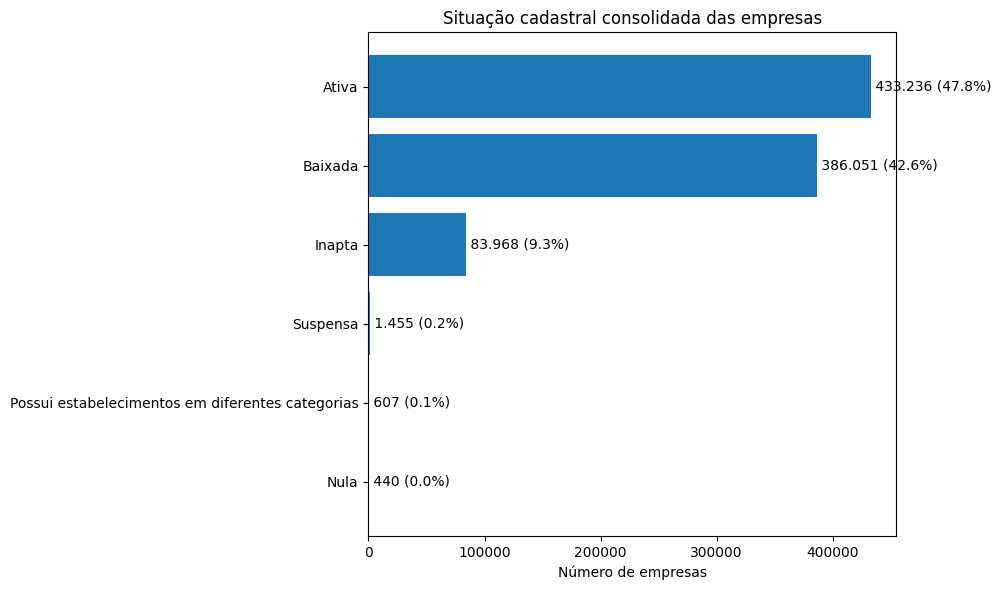

In [210]:
dados = resumo_situacao_empresas.sort_values("empresas",ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.barh( dados["situacao_empresa"],dados["empresas"])
   
ax.set_title("Situação cadastral consolidada das empresas")
ax.set_xlabel("Número de empresas")
ax.set_ylabel("")

for barra, valor, percentual in zip(
    barras,
    dados["empresas"],
    dados["percentual"]
):
    ax.text(
        barra.get_width(),
        barra.get_y() + barra.get_height() / 2,
        f" {valor:,.0f} ({percentual:.1f}%)".replace(",", "."),
        va="center"
    )

plt.tight_layout()
plt.show()

A classificação consolidada apresenta resultado muito próximo ao obtido pela primeira heurística.

Enquanto **433.735 empresas (47,89%)** possuem pelo menos um estabelecimento ativo, **433.236 empresas (47,83%)** possuem todos os estabelecimentos observados classificados como ativos.

A diferença entre as duas definições é de apenas **499 empresas**.

Além disso, somente **607 empresas (0,07%)** apresentam estabelecimentos distribuídos entre diferentes situações cadastrais. Isso indica que, na amostra analisada, é pouco comum uma mesma empresa possuir estabelecimentos em categorias cadastrais distintas.

Dessa forma, a definição inicial — considerar ativa a empresa que possui pelo menos um estabelecimento ativo — produz um resultado bastante próximo de uma classificação mais restritiva baseada na situação de todos os estabelecimentos.

#### Quantidade de estabelecimentos por empresa

Uma possível explicação para a semelhança entre as duas classificações é a quantidade de estabelecimentos associados a cada empresa.

Empresas com apenas um estabelecimento necessariamente apresentam a mesma classificação nas duas abordagens, pois não existe a possibilidade de haver situações cadastrais diferentes dentro da empresa.

Por isso, foi analisada a proporção de empresas que possuem um ou mais estabelecimentos na amostra.

In [211]:
resumo_estabelecimentos = con.sql("""
    WITH empresas AS (
        SELECT
            cnpj_basico,
            COUNT(*) AS qtd_estabelecimentos
        FROM gold.analise
        GROUP BY cnpj_basico
    )

    SELECT
        COUNT(*) AS total_empresas,

        COUNT(*) FILTER (
            WHERE qtd_estabelecimentos = 1
        ) AS empresas_um_estabelecimento,

        COUNT(*) FILTER (
            WHERE qtd_estabelecimentos > 1
        ) AS empresas_multiplos_estabelecimentos

    FROM empresas
""").df()

resumo_estabelecimentos

,total_empresas,empresas_um_estabelecimento,empresas_multiplos_estabelecimentos
0,905757,902462,3295


In [212]:
con.sql("""
    WITH empresas AS (
        SELECT
            cnpj_basico,
            COUNT(*) AS qtd_estabelecimentos,
            COUNT(
                DISTINCT COALESCE(
                    situacao_cadastral_descricao,
                    'Não informado'
                )
            ) AS qtd_situacoes

        FROM gold.analise
        GROUP BY cnpj_basico
    )

    SELECT
        COUNT(*) AS empresas_multiplos_estabelecimentos,

        COUNT(*) FILTER (
            WHERE qtd_situacoes = 1
        ) AS mesma_situacao,

        COUNT(*) FILTER (
            WHERE qtd_situacoes > 1
        ) AS situacoes_diferentes,

        ROUND(
            100.0 * COUNT(*) FILTER (
                WHERE qtd_situacoes > 1
            ) / COUNT(*),
            2
        ) AS percentual_situacoes_diferentes

    FROM empresas

    WHERE qtd_estabelecimentos > 1
""").df()

,empresas_multiplos_estabelecimentos,mesma_situacao,situacoes_diferentes,percentual_situacoes_diferentes
0,3295,2688,607,18.42



A proximidade entre os resultados das duas heurísticas pode ser explicada pela estrutura da própria amostra.

Das **905.757 empresas analisadas**, **902.462 (99,64%) possuem apenas um estabelecimento**, enquanto somente **3.295 (0,36%) possuem mais de um estabelecimento**.

Para empresas com apenas um estabelecimento, as duas formas de classificação produzem necessariamente o mesmo resultado, pois não existe a possibilidade de haver diferentes situações cadastrais dentro da empresa.

Entre as **3.295 empresas com múltiplos estabelecimentos**, **2.688 (81,58%)** apresentam a mesma situação cadastral em todos eles. Apenas **607 empresas (18,42%)** possuem estabelecimentos em categorias diferentes.

Isso explica por que as duas heurísticas de classificação produziram resultados tão semelhantes: além de empresas com múltiplos estabelecimentos serem raras na amostra, a maioria delas também apresenta uma situação cadastral uniforme.

#### Interpretação das situações cadastrais

- **Ativa — 433.236 empresas (47,83%)**: corresponde aos casos em que o CNPJ não se enquadra nas situações de suspensão, inaptidão, baixa ou nulidade. É importante observar que situação cadastral ativa não significa necessariamente ausência de débitos tributários, pois situação cadastral e situação fiscal são conceitos diferentes.

- **Baixada — 386.051 empresas (42,62%)**: ocorre quando a inscrição no CNPJ é encerrada. Isso pode acontecer, por exemplo, após encerramento da empresa, liquidação, incorporação, fusão, cisão total ou encerramento de falência. A Receita também pode realizar a baixa de ofício em determinadas situações previstas na legislação.

- **Inapta — 83.968 empresas (9,27%)**: representa uma situação de irregularidade mais grave. Uma causa comum é a omissão prolongada na entrega de declarações e escriturações obrigatórias; a legislação também prevê outras hipóteses de irregularidade que podem levar à inaptidão. A empresa permanece inscrita no CNPJ, mas sofre diversas restrições enquanto não regularizar a situação.

- **Suspensa — 1.455 empresas (0,16%)**: geralmente representa uma situação temporária ou um problema cadastral ainda em análise. Entre as causas estão interrupção temporária das atividades, inconsistências nos dados cadastrais, impossibilidade de localizar a empresa no endereço informado, ordem judicial ou procedimentos administrativos relacionados a outras irregularidades.

- **Nula — 440 empresas (0,05%)**: ocorre quando a própria inscrição ou algum ato cadastral é considerado inválido. Pode acontecer, por exemplo, em casos de inscrição criada indevidamente, fraude cadastral ou atribuição de mais de um número de CNPJ ao mesmo estabelecimento.


A maior parte da amostra está concentrada entre as situações **Ativa (47,83%)** e **Baixada (42,62%)**. A categoria **Inapta**, com 9,27%, também possui participação relevante, enquanto situações suspensas e nulas representam parcelas pequenas da amostra.

### 5.2 Como evoluiu a abertura de empresas do setor nos últimos 5 anos?

A `data_inicio_atividade` disponível na base representa a data de início de atividade de cada estabelecimento. Como uma empresa pode possuir mais de um estabelecimento, contar diretamente as linhas da tabela poderia contabilizar a abertura de uma filial como a abertura de uma nova empresa.

Para evitar essa duplicidade, será considerada como referência de abertura da empresa a **menor `data_inicio_atividade` observada para cada `cnpj_basico` na amostra**.

Nesta análise não é aplicado filtro pela situação cadastral atual. Uma empresa que foi aberta em determinado ano é contabilizada naquele período mesmo que atualmente esteja baixada, inapta ou suspensa.

In [213]:
abertura_empresas = con.sql("""
    SELECT
        cnpj_basico,
        MIN(data_inicio_atividade) AS data_abertura
    FROM gold.analise
    WHERE data_inicio_atividade IS NOT NULL
    GROUP BY cnpj_basico
""").df()

abertura_empresas.head()

,cnpj_basico,data_abertura
0,49455009,1982-03-30
1,52275948,1983-02-09
2,53944955,1984-11-19
3,53948091,2024-02-17
4,53865523,1984-09-28


#### Evolução mensal das aberturas

Para observar com maior detalhe a evolução identificada na análise anual, as aberturas foram agrupadas por mês.

A visualização mensal permite identificar mudanças de tendência e possíveis períodos de maior ou menor volume de abertura que ficam ocultos quando os dados são agregados apenas por ano.

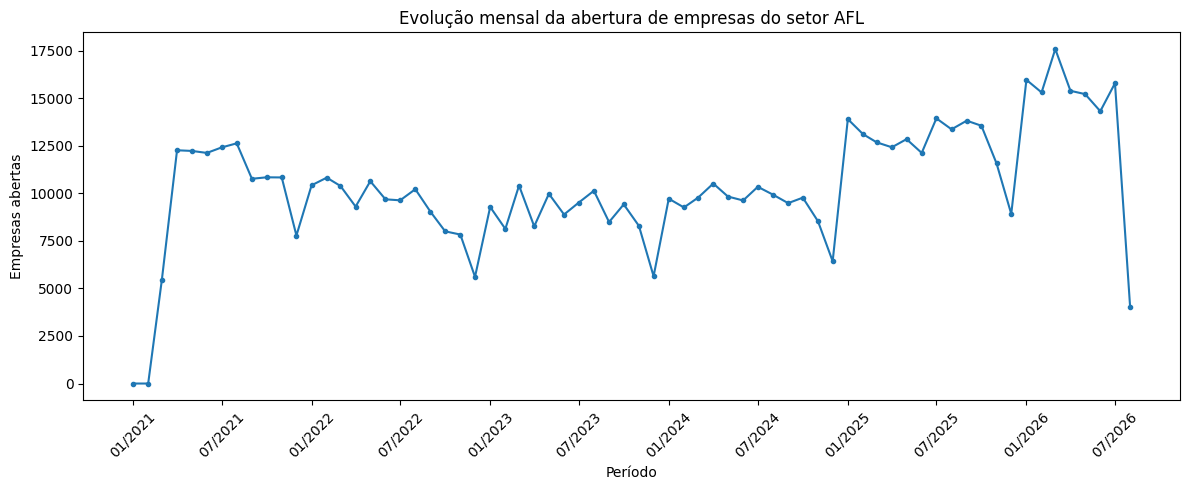

In [214]:
# Garante que a coluna está no formato de data
abertura_empresas["data_abertura"] = pd.to_datetime(abertura_empresas["data_abertura"])

# Filtra o período analisado
aberturas_mensais = (
    abertura_empresas[
        abertura_empresas["data_abertura"].dt.year >= 2021
    ]
    .assign(
        mes=lambda df: df["data_abertura"].dt.to_period("M")
    )
    .groupby("mes")
    .size()
    .reset_index(name="empresas_abertas")
)

# Converte o período para timestamp para facilitar o gráfico
aberturas_mensais["mes"] = aberturas_mensais["mes"].dt.to_timestamp()

import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    aberturas_mensais["mes"],
    aberturas_mensais["empresas_abertas"],
    marker="o",
    markersize=3
)

ax.set_title("Evolução mensal da abertura de empresas do setor AFL")
ax.set_xlabel("Período")
ax.set_ylabel("Empresas abertas")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y"))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Além da tendência de crescimento observada a partir de 2025, a análise mensal revela um padrão que se repete ao longo dos anos.

Entre 2022 e 2025, observa-se uma **redução recorrente no número de aberturas nos últimos meses de cada ano**, seguida por uma **recuperação acentuada no início do ano seguinte**. Os menores valores anuais aparecem frequentemente próximos ao final do ano, enquanto janeiro e os primeiros meses do ano apresentam uma retomada do número de novas empresas.

Apesar desse padrão sazonal, o nível geral da série também se modifica. Entre 2022 e 2024, as aberturas permanecem majoritariamente próximas de 8 mil a 10 mil empresas por mês. Em 2025 ocorre uma mudança de patamar, com valores frequentemente acima de 12 mil, e em 2026 os primeiros meses alcançam níveis ainda maiores.

Portanto, o gráfico sugere a presença simultânea de dois fenômenos: uma **sazonalidade anual**, caracterizada pela queda no final do ano e recuperação no início do seguinte, e uma **tendência de crescimento no volume de aberturas a partir de 2025**.


#### Evolução anual das aberturas

A análise mensal evidencia a presença de sazonalidade ao longo do ano. Para observar com maior clareza a tendência de longo prazo, as aberturas também são agregadas por ano.

Essa visão reduz as oscilações mensais e permite comparar o volume total de empresas abertas em cada período.

In [215]:
aberturas_anuais = con.sql("""
    WITH abertura_empresas AS (
        SELECT
            cnpj_basico,
            MIN(data_inicio_atividade) AS data_abertura
        FROM gold.analise
        WHERE data_inicio_atividade IS NOT NULL
        GROUP BY cnpj_basico
    )

    SELECT
        YEAR(data_abertura) AS ano,
        COUNT(*) AS empresas_abertas
    FROM abertura_empresas
    WHERE YEAR(data_abertura) BETWEEN 2021 AND 2026
    GROUP BY ano
    ORDER BY ano
""").df()

aberturas_anuais

,ano,empresas_abertas
0,2021,107317
1,2022,111552
2,2023,106403
3,2024,113182
4,2025,152203
5,2026,113536


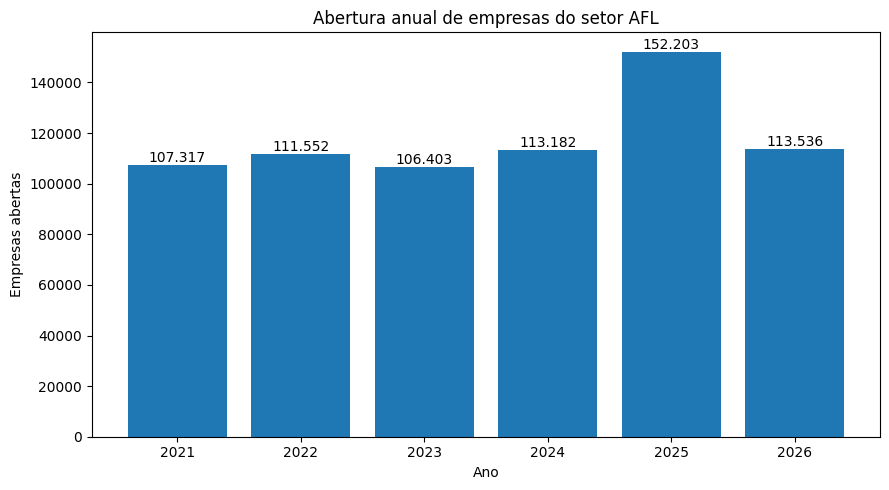

In [216]:
fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.bar( aberturas_anuais["ano"].astype(str), aberturas_anuais["empresas_abertas"])

ax.set_title("Abertura anual de empresas do setor AFL")
ax.set_xlabel("Ano")
ax.set_ylabel("Empresas abertas")

for barra, valor in zip(
    barras,
    aberturas_anuais["empresas_abertas"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{valor:,.0f}".replace(",", "."),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#### Interpretação da evolução anual

A agregação anual confirma o comportamento observado na série mensal.

Entre **2021 e 2024**, o número de empresas abertas permaneceu relativamente estável, oscilando entre aproximadamente **106 mil e 113 mil aberturas por ano**. Nesse período não se observa uma tendência contínua de crescimento ou queda, mas pequenas variações anuais.

Em **2025**, ocorre uma mudança significativa nesse padrão. Foram registradas **152.203 aberturas**, crescimento de aproximadamente **34,5% em relação a 2024**, representando o maior volume anual observado na série.

Em **2026**, já foram observadas **113.536 aberturas**. Como a base corresponde a um período ainda incompleto do ano, esse valor não pode ser comparado diretamente aos totais dos anos anteriores. Ainda assim, o número já supera os totais anuais registrados entre 2021 e 2024.

A análise anual, portanto, reforça o resultado observado na série mensal: após um período de relativa estabilidade entre 2021 e 2024, o setor apresenta uma elevação expressiva no número de novas empresas a partir de 2025.

### 5.3 Qual o porte predominante nesses estabelecimentos?

Para responder a esta pergunta, é necessário distinguir as diferentes classificações empresariais presentes na base.

A tabela de **Empresas** possui o campo `porte`, que permite identificar **Microempresas (ME)**, **Empresas de Pequeno Porte (EPP)**, empresas classificadas como **Demais** e registros em que o porte não foi informado. Entretanto, esse campo não permite identificar diretamente os **Microempreendedores Individuais (MEI)**. 

A identificação do MEI foi realizada utilizando os **Dados do Simples**, que possuem o campo `opcao_mei`, indicando se a empresa é optante pelo MEI.

Combinando as informações das duas fontes, foi criada na camada Gold a variável `classificacao_porte`, seguindo a seguinte regra:

- `opcao_mei = 'S'` → **MEI**
- `porte = 01` → **ME**
- `porte = 03` → **EPP**
- `porte = 05` → **Demais**
- demais casos → **Não informado**

Essa classificação permite analisar separadamente os MEIs das demais Microempresas e responder de forma mais completa à pergunta proposta.

#### Classificações utilizadas

Para esta análise, serão consideradas as seguintes categorias:

- **MEI — Microempreendedor Individual:** modalidade simplificada destinada a pequenos empreendedores individuais. Além de possuir regras próprias, o MEI deve ser optante pelo Simples Nacional e está sujeito a um limite específico de receita bruta anual. Atualmente, o limite geral é de **R$ 81 mil por ano**. 

- **ME — Microempresa:** empresa enquadrada como Microempresa. Pela legislação, corresponde, em regra, às empresas com receita bruta anual de até **R$ 360 mil**.

- **EPP — Empresa de Pequeno Porte:** corresponde, em regra, às empresas com receita bruta anual superior a **R$ 360 mil** e de até **R$ 4,8 milhões**.

- **Demais:** categoria utilizada na base da Receita Federal para empresas que não estão enquadradas como ME ou EPP. Essa categoria não deve ser interpretada diretamente como "grande empresa", pois reúne os demais enquadramentos presentes na base.

- **Não informado:** corresponde aos registros em que o porte não está informado na base da Receita Federal.

In [217]:
porte_estabelecimentos = con.sql("""
    SELECT
        classificacao_porte AS porte,
        COUNT(*) AS estabelecimentos,

        ROUND(
            100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),2 ) AS percentual
            
    FROM gold.analise

    GROUP BY classificacao_porte
    ORDER BY estabelecimentos DESC
""").df()

porte_estabelecimentos

,porte,estabelecimentos,percentual
0,ME,387454,42.45
1,MEI,365327,40.03
2,Demais,140112,15.35
3,EPP,19736,2.16


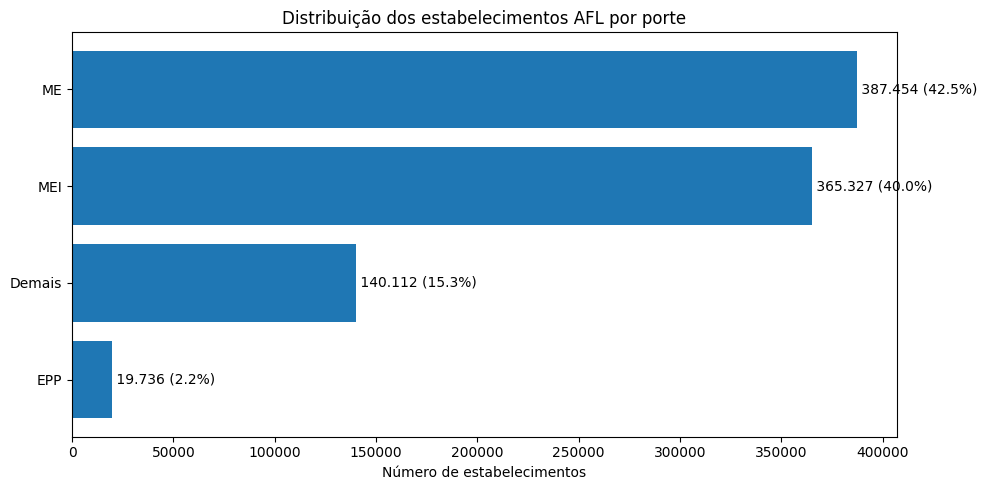

In [218]:
dados = porte_estabelecimentos.sort_values( "estabelecimentos",ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

barras = ax.barh(
    dados["porte"],
    dados["estabelecimentos"]
)

ax.set_title("Distribuição dos estabelecimentos AFL por porte")
ax.set_xlabel("Número de estabelecimentos")
ax.set_ylabel("")

for barra, valor, percentual in zip(
    barras,
    dados["estabelecimentos"],
    dados["percentual"]
):
    ax.text(
        barra.get_width(),
        barra.get_y() + barra.get_height() / 2,
        f" {valor:,.0f} ({percentual:.1f}%)".replace(",", "."),
        va="center"
    )

plt.tight_layout()
plt.show()

#### Interpretação

A distribuição mostra forte predominância de pequenos negócios entre os estabelecimentos.

As **Microempresas (ME)** representam a maior categoria da amostra, com **387.454 estabelecimentos (42,5%)**. Logo em seguida aparecem os **Microempreendedores Individuais (MEI)**, com **365.327 estabelecimentos (40,0%)**.

Somadas, essas duas categorias correspondem a aproximadamente **82,5% dos estabelecimentos analisados**, indicando uma forte concentração do setor em negócios de menor porte.

Os estabelecimentos classificados como **Demais** representam **140.112 registros (15,3%)**, enquanto as **Empresas de Pequeno Porte (EPP)** possuem participação consideravelmente menor, com **19.736 estabelecimentos (2,2%)**.

Portanto, considerando a classificação utilizada nesta análise, o **porte predominante é ME**, embora a participação dos **MEIs seja muito próxima**. Mais do que uma concentração isolada em uma única categoria, os dados mostram que **ME e MEI dominam conjuntamente a estrutura empresarial observada no setor AFL**.


## Conclusão

A análise permitiu caracterizar a amostra de estabelecimentos do setor AFL a partir da integração dos dados de **Empresas**, **Estabelecimentos** e **Dados do Simples** da Receita Federal.

Em relação à situação cadastral, aproximadamente **47,8% das empresas analisadas estão ativas**, enquanto a maior parte das demais encontra-se principalmente nas categorias **Baixada** e **Inapta**.

A evolução das aberturas mostra um comportamento relativamente estável entre **2021 e 2024**, seguido por um crescimento expressivo em **2025**. Em **2026**, mesmo com dados ainda parciais, o número de novas empresas já supera os totais anuais observados entre 2021 e 2024, indicando manutenção de um nível elevado de abertura de novos negócios.

Quanto ao porte, observa-se forte concentração em negócios de menor porte. As **Microempresas (ME)** representam **42,5%** dos estabelecimentos e os **Microempreendedores Individuais (MEI)**, **40,0%**. Juntas, essas duas categorias correspondem a aproximadamente **82,5% da amostra**, evidenciando a predominância de pequenos negócios no setor analisado.


In [233]:
con.close()